# BERT Sentiment — autoLRP attribution

Which words drive BERT's positive/negative sentiment prediction? Uses `textattack/bert-base-uncased-SST-2`.

In [1]:
import sys
sys.path.insert(0, '..')          # examples/showcase: _common
sys.path.insert(0, '../../..')    # repo root: autoLRP (or `pip install -e .`)
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

import autoLRP as autolrp
from autoLRP import LRPConfig
from _common import show_text_attribution

device = 'cuda' if torch.cuda.is_available() else 'cpu'

/opt/miniconda3/envs/waleed/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tok = AutoTokenizer.from_pretrained('textattack/bert-base-uncased-SST-2')
model = AutoModelForSequenceClassification.from_pretrained(
    'textattack/bert-base-uncased-SST-2').eval().to(device)

LABELS = ['Negative', 'Positive']

class BertClf(torch.nn.Module):
    """Embeddings -> sentiment logits."""
    def __init__(self, m):
        super().__init__()
        self.encoder = m.bert.encoder
        self.pooler = m.bert.pooler
        self.classifier = m.classifier
    def forward(self, x):
        enc = self.encoder(x).last_hidden_state
        pooled = self.pooler(enc)
        return self.classifier(pooled)

wrapper = BertClf(model).eval().to(device)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 43226.94it/s]


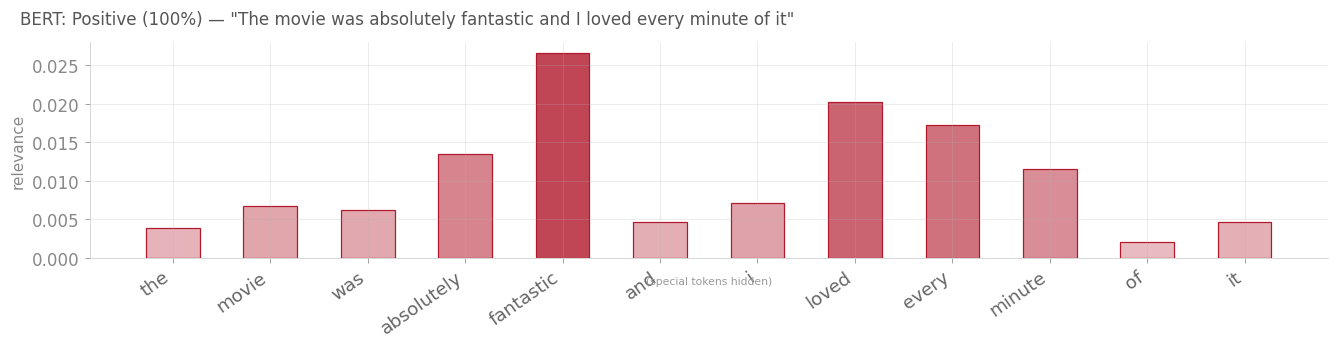

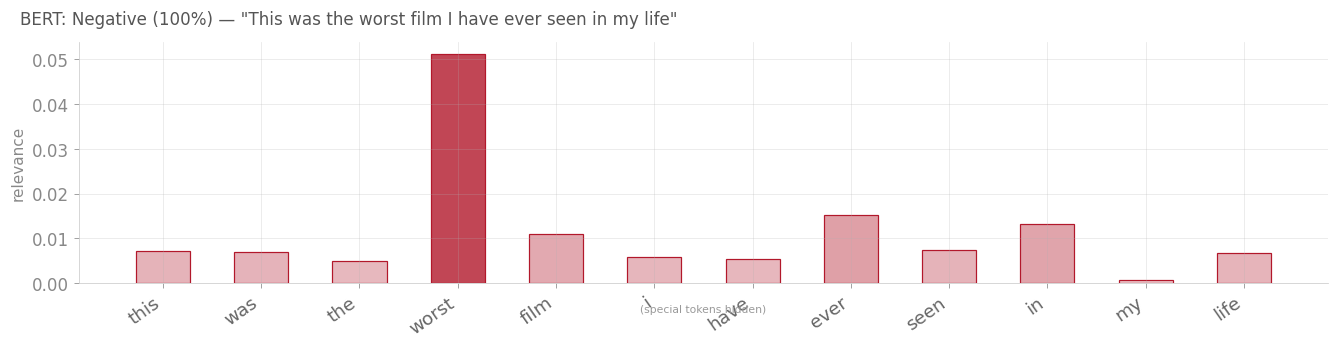

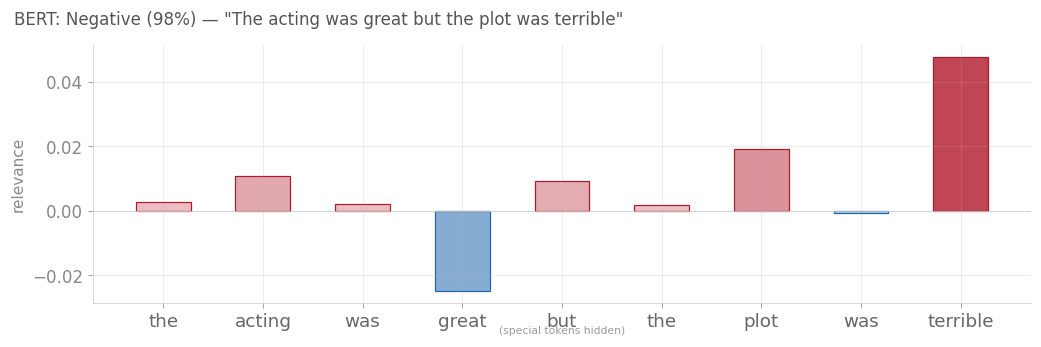

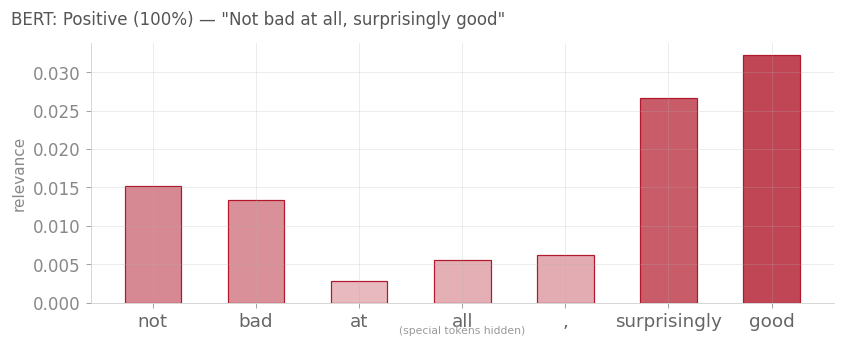

In [3]:
SENTENCES = [
    'The movie was absolutely fantastic and I loved every minute of it',
    'This was the worst film I have ever seen in my life',
    'The acting was great but the plot was terrible',
    'Not bad at all, surprisingly good',
]

for si, text in enumerate(SENTENCES):
    inputs = tok(text, return_tensors='pt').to(device)
    emb = model.bert.embeddings(inputs['input_ids']).detach()

    with torch.no_grad():
        logits = wrapper(emb)
        pred = logits.argmax(-1).item()
        prob = torch.softmax(logits, -1)[0, pred].item()

    x = autolrp.tensor(emb)
    out = wrapper(x)
    out[0, pred].lrp()                      # BASE: epsilon on every linear layer and both attention products


    tokens = tok.convert_ids_to_tokens(inputs['input_ids'][0])
    rel = x.relevance[0].sum(-1).detach().cpu().numpy()

    show_text_attribution(
        tokens, rel,
        title=f'BERT: {LABELS[pred]} ({prob:.0%}) — "{text}"',
    )